# Adaptive Smooth

dmimgadapt

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./

CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [5]:
/bin/rm -rf 13201
download_chandra_obsid 13201 


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      11 Kb  ####################          < 1 s  1811.1 kb/s
  oif      fits       25 Kb  ####################          < 1 s  3517.6 kb/s
  vv       pdf        44 Kb  ####################          < 1 s  5978.2 kb/s
  cntr_img fits      131 Kb  ####################          < 1 s  12154.5 kb/s
  cntr_img jpg       685 Kb  ####################          < 1 s  24254.7 kb/s
  evt2     fits        9 Mb  ####################          < 1 s  65356.5 kb/s
  full_img fits       68 Kb  ####################          < 1 s  4718.2 kb/s
  full_img jpg        65 Kb  ####################          < 1 s  3834.9 kb/s
  bpix     fits       68 Kb  ####################          < 1 s  5359.9 kb/s
  fov      fits        6 Kb  ####################          < 1 s  709.6 kb/s
  eph1     fits      310 Kb  ####################          < 

In [6]:
chandra_repro 13201 out=./


Processing input directory '/data/sdsreg/thread_output/CIAO4.9/adaptive_smooth/13201'

Resetting afterglow status bits in evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/sdsreg/thread_output/CIAO4.9/adaptive_smooth/acisf13201_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...
Setting observation-specific bad pixel file in local ardlib.par.

Cleaning up intermediate files

         /data/sdsreg/thread_output/CIAO4.9/adaptive_smooth/acisf13201_repro_bpix1.fits
         Run 'punlearn ardlib' when analysis of this dataset completed.

The data have been reprocessed.
Start your analysis with the new products in
/data/sdsreg/thread_output/CIAO4.9/adaptive_smooth



In [7]:
fluximage infile='acisf13201_repro_evt2.fits[ccd_id=0:3]' \
  outroot='abell_665' bands='broad' binsize='2' \
  mode=h clob+ verb=1

Running fluximage
Version: 12 September 2016

Using CSC ACIS broad science energy band.
Aspect solution pcadf410735608N002_asol1.fits found.
Bad-pixel file acisf13201_repro_bpix1.fits found.
Mask file acisf13201_000N002_msk1.fits found.

The output images will have 1405 by 1406 pixels, pixel size of 0.984 arcsec,
    and cover x=2606.5:5416.5:2,y=2864.5:5676.5:2.

Running tasks in parallel with 4 processors.
Creating aspect histograms for obsid 13201
Creating 4 instrument maps for obsid 13201
Creating 4 exposure maps for obsid 13201
Combining 4 exposure maps for obsid 13201
Thresholding data for obsid 13201
Exposure-correcting image for obsid 13201

The following files were created:

 The clipped counts image is:
     abell_665_broad_thresh.img

 The clipped exposure map is:
     abell_665_broad_thresh.expmap

 The exposure-corrected image is:
     abell_665_broad_flux.img



## Shrink fov to just include ccds

In [8]:
dmcopy "acisf13201_000N002_fov1.fits[ccd_id=0:3]" fov.fits cl+


In [9]:
dmcopy "abell_665_broad_thresh.img[sky=region(fov.fits)][opt full]" broad.img cl+
dmcopy "abell_665_broad_thresh.expmap[sky=region(fov.fits)][opt full]" broad.expmap cl+

In [10]:
dmlist broad.img subspace

 
--------------------------------------------------------------------------------
Data subspace for block EVENTS_IMAGE: Components: 4 Descriptors: 17 
--------------------------------------------------------------------------------
 
 --- Component 1 --- 
   1 sky                  Real8               Polygon(4954.3,4722.64,4954.3,4766.89,4495.24,5676.15,4494.76,5676.27,4445.45,5676.17,3536.97,5220.03,3536.97,5175.79,3996.12,4266.7,4045.8,4266.68,4045.86,4266.71,4954.3,4722.64)|Polygon(2607.51,4754.15,2607.51,4709.91,3062.23,3798.46,3112.04,3798.19,4020.36,4254.36,4020.42,4254.39,4020.41,4298.64,3565.89,5210.05,3516.46,5210.2,2607.71,4754.6,2607.51,4754.15)|Rectangle(2607.51,2865.98,5416.5,5676.27)&Polygon(4461.96,3332.7,4511.89,3332.81,5420.51,3788.68,5420.59,3789.08,5420.59,3833.33,4965.84,4744.35,4965.65,4744.61,4916.09,4744.38,4007.66,4288.42,4007.66,4244.17,4461.96,3332.7)|Polygon(3073.98,3819.88,3073.98,3775.64,3074.07,3775.33,3532.77,2866.29,3533.15,2866.12,3583.2,2865.98,4491.5

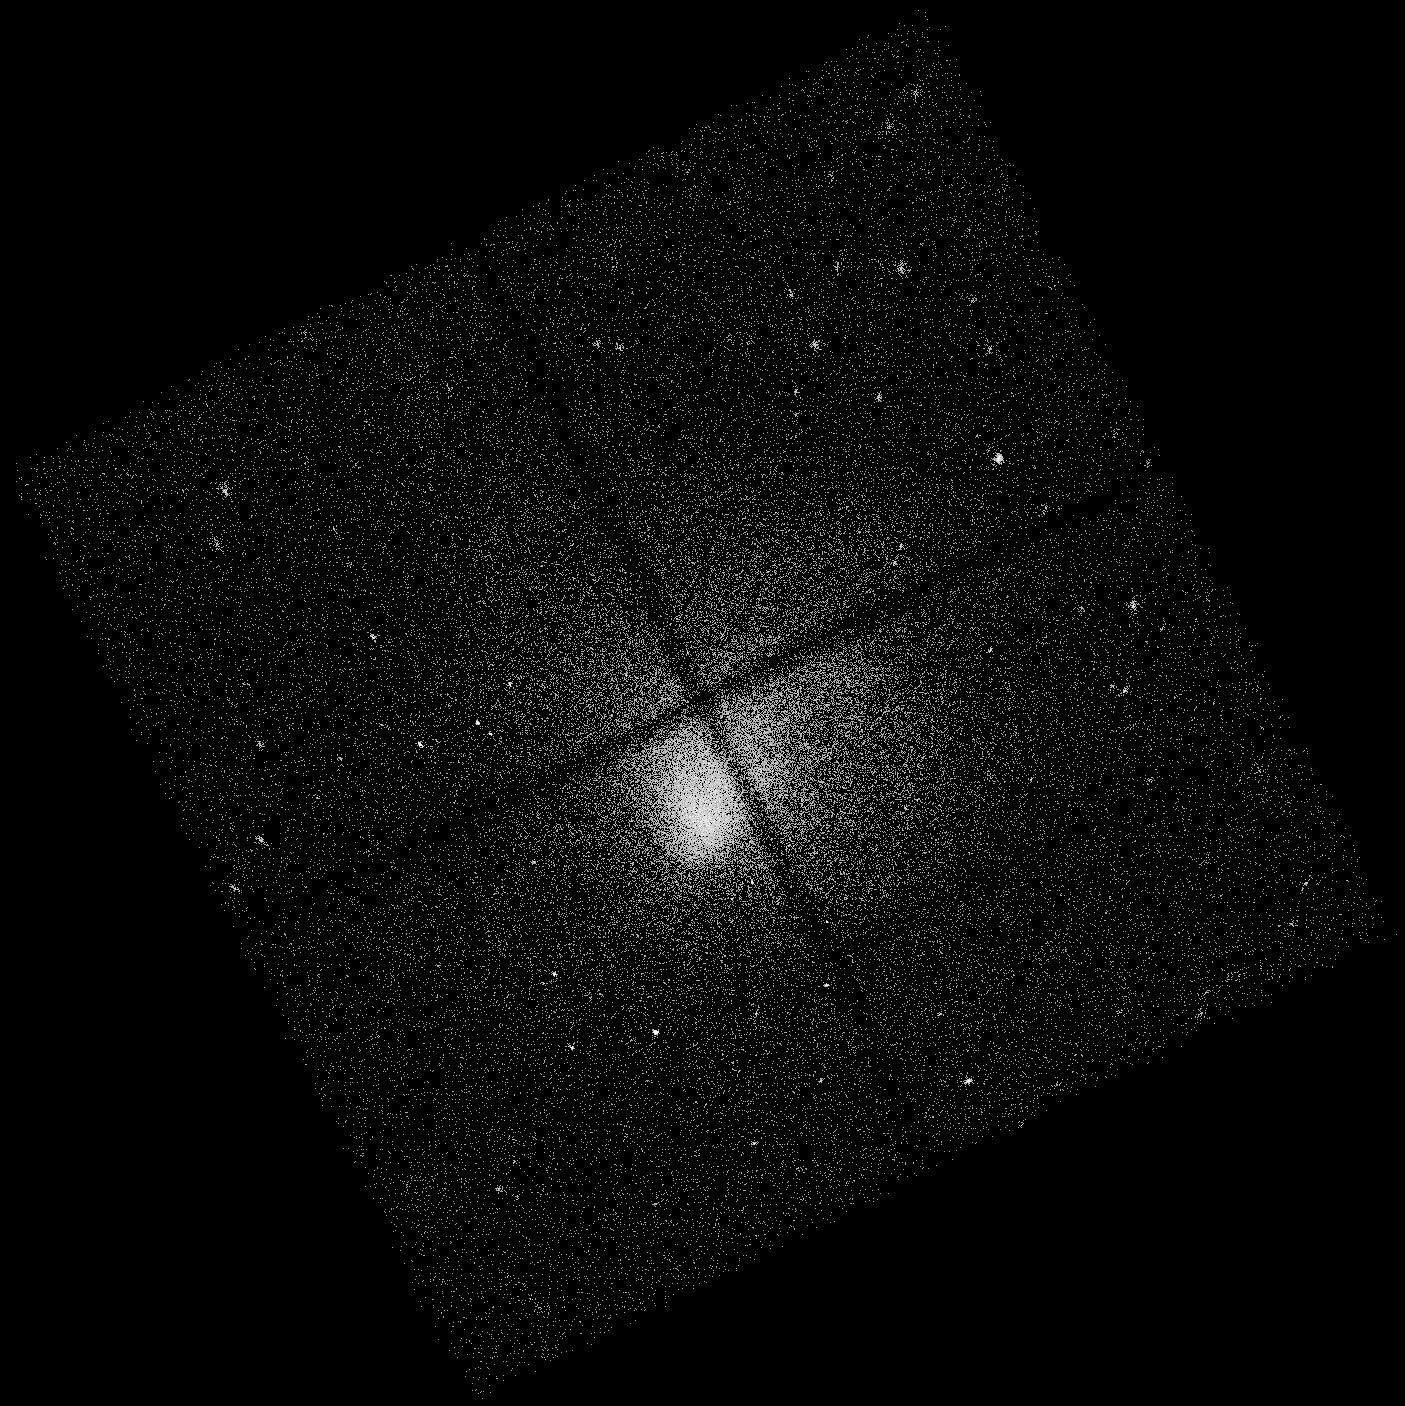

In [11]:
dmimg2jpg broad.img outfile=broad_img.jpg maxred=10 mode=h clob+
display < broad_img.jpg


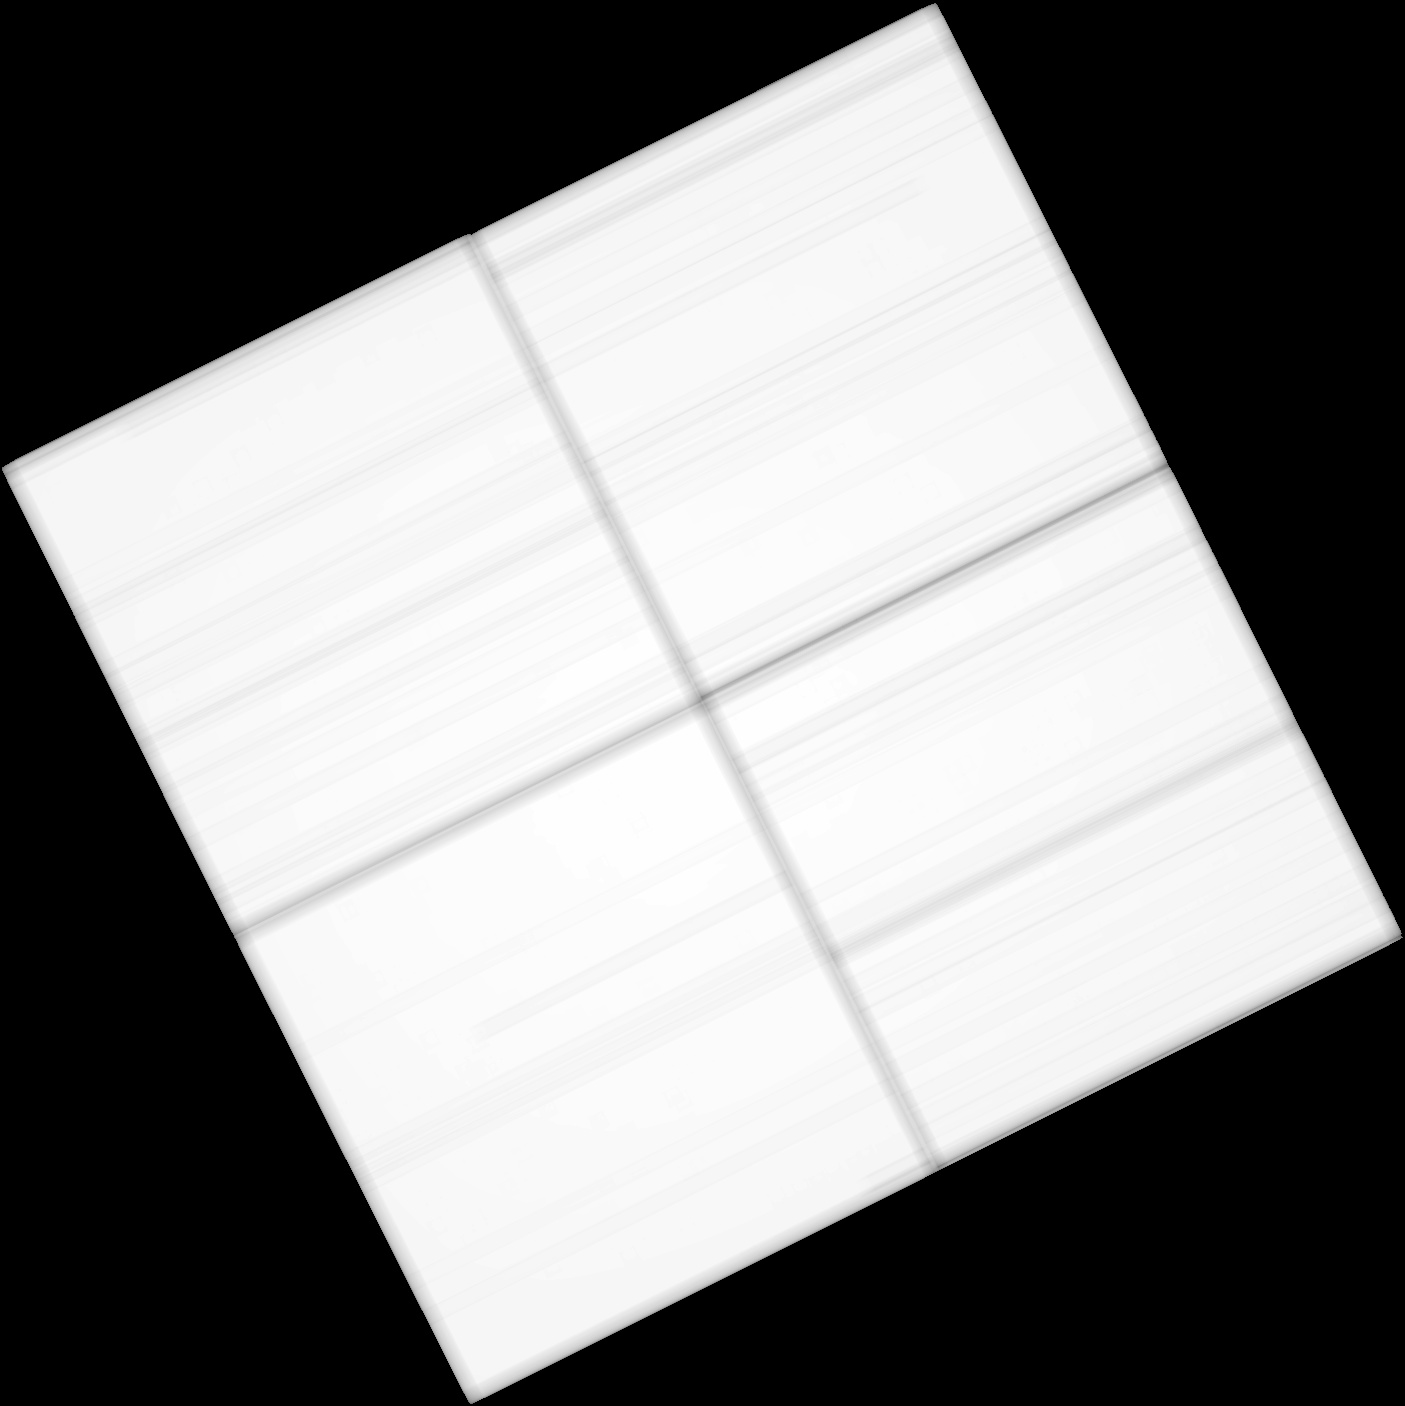

In [12]:
dmimg2jpg broad.expmap outfile=broad_expmap.jpg mode=h clob+ minred=0
display < broad_expmap.jpg

##  Adaptive smooth: counts


In [13]:
punlearn dmimgadapt
pset dmimgadapt \
  infile=broad.img \
  outfile=broad_smooth.img \
  counts=25 \
  radfile=broad.radii \
  normfile=broad.norm \
  function=quad \
  minrad=0.5 \
  maxrad=30 \
  numrad=50 \
  radscale=log
dmimgadapt mode=h clobber=yes

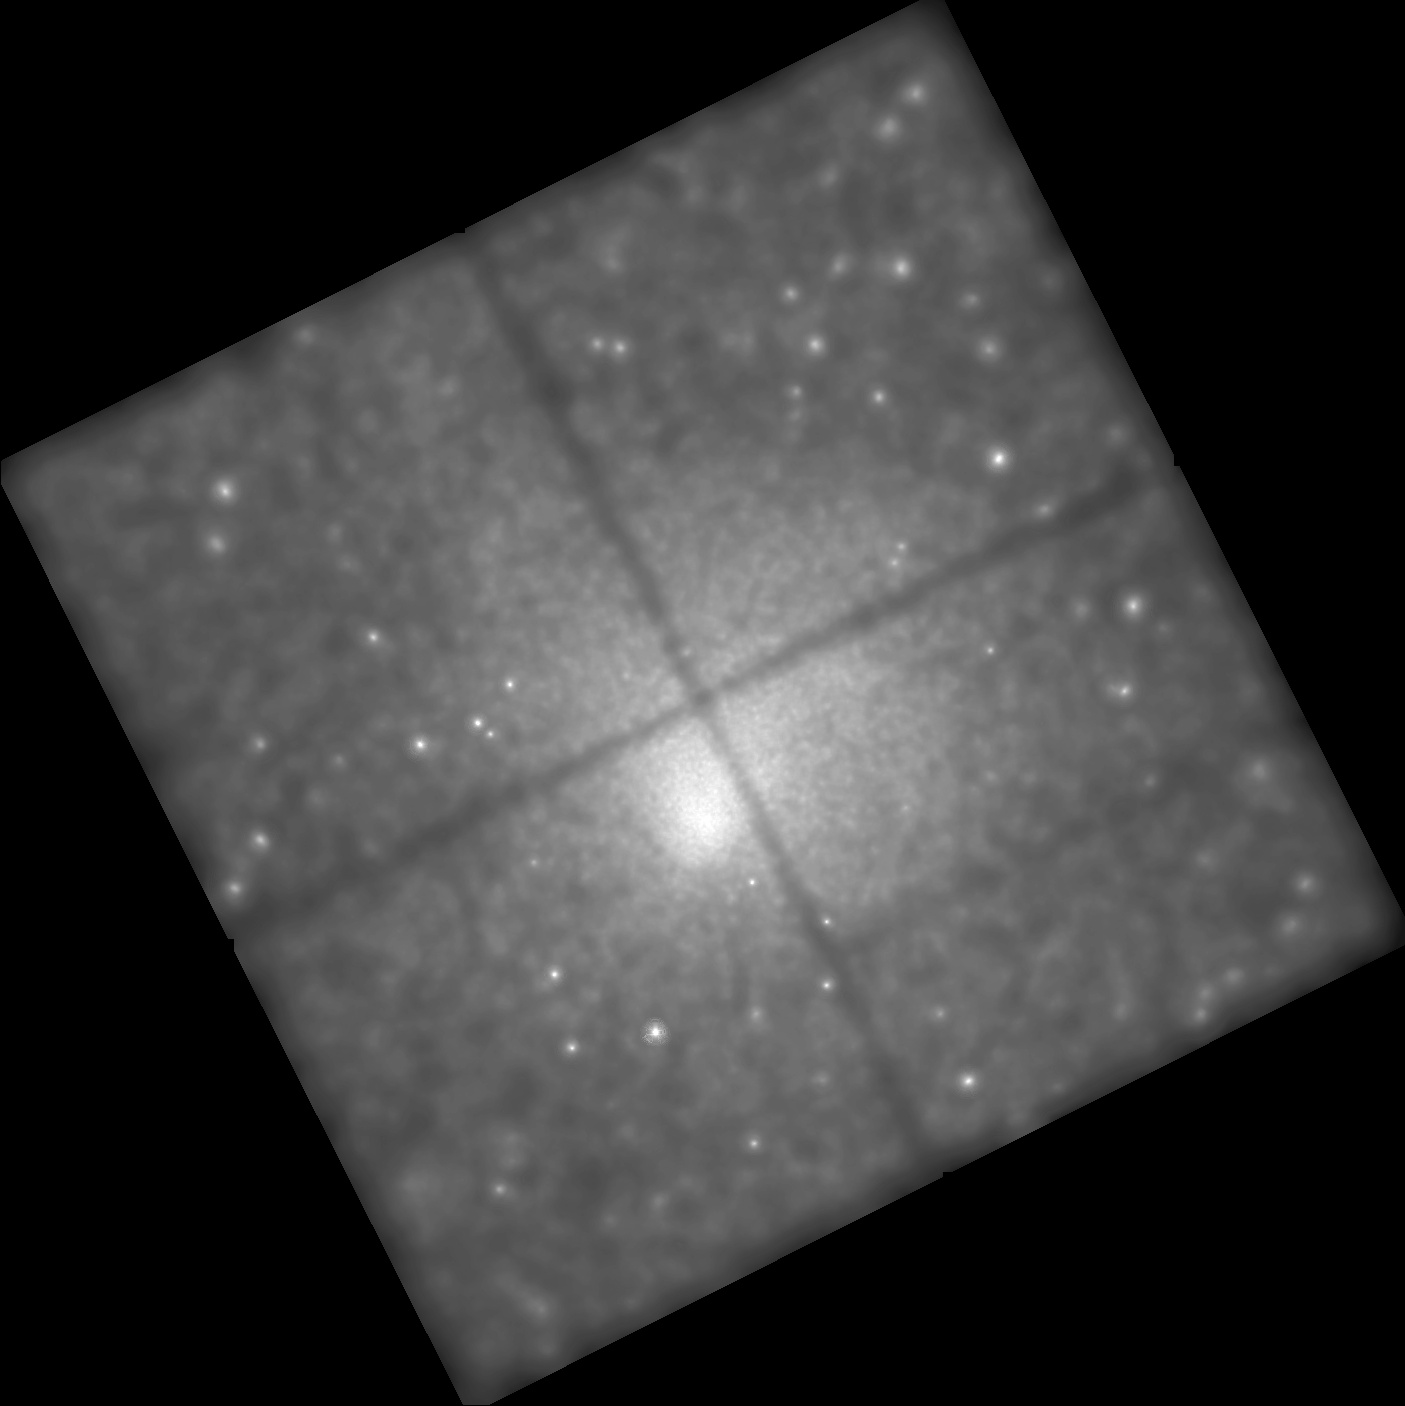

In [14]:
punlearn dmimg2jpg
dmimg2jpg broad_smooth.img outfile=broad_smooth.jpg scalefun=log \
  maxred=4 minred=0.0 mode=h clob+
display < broad_smooth.jpg

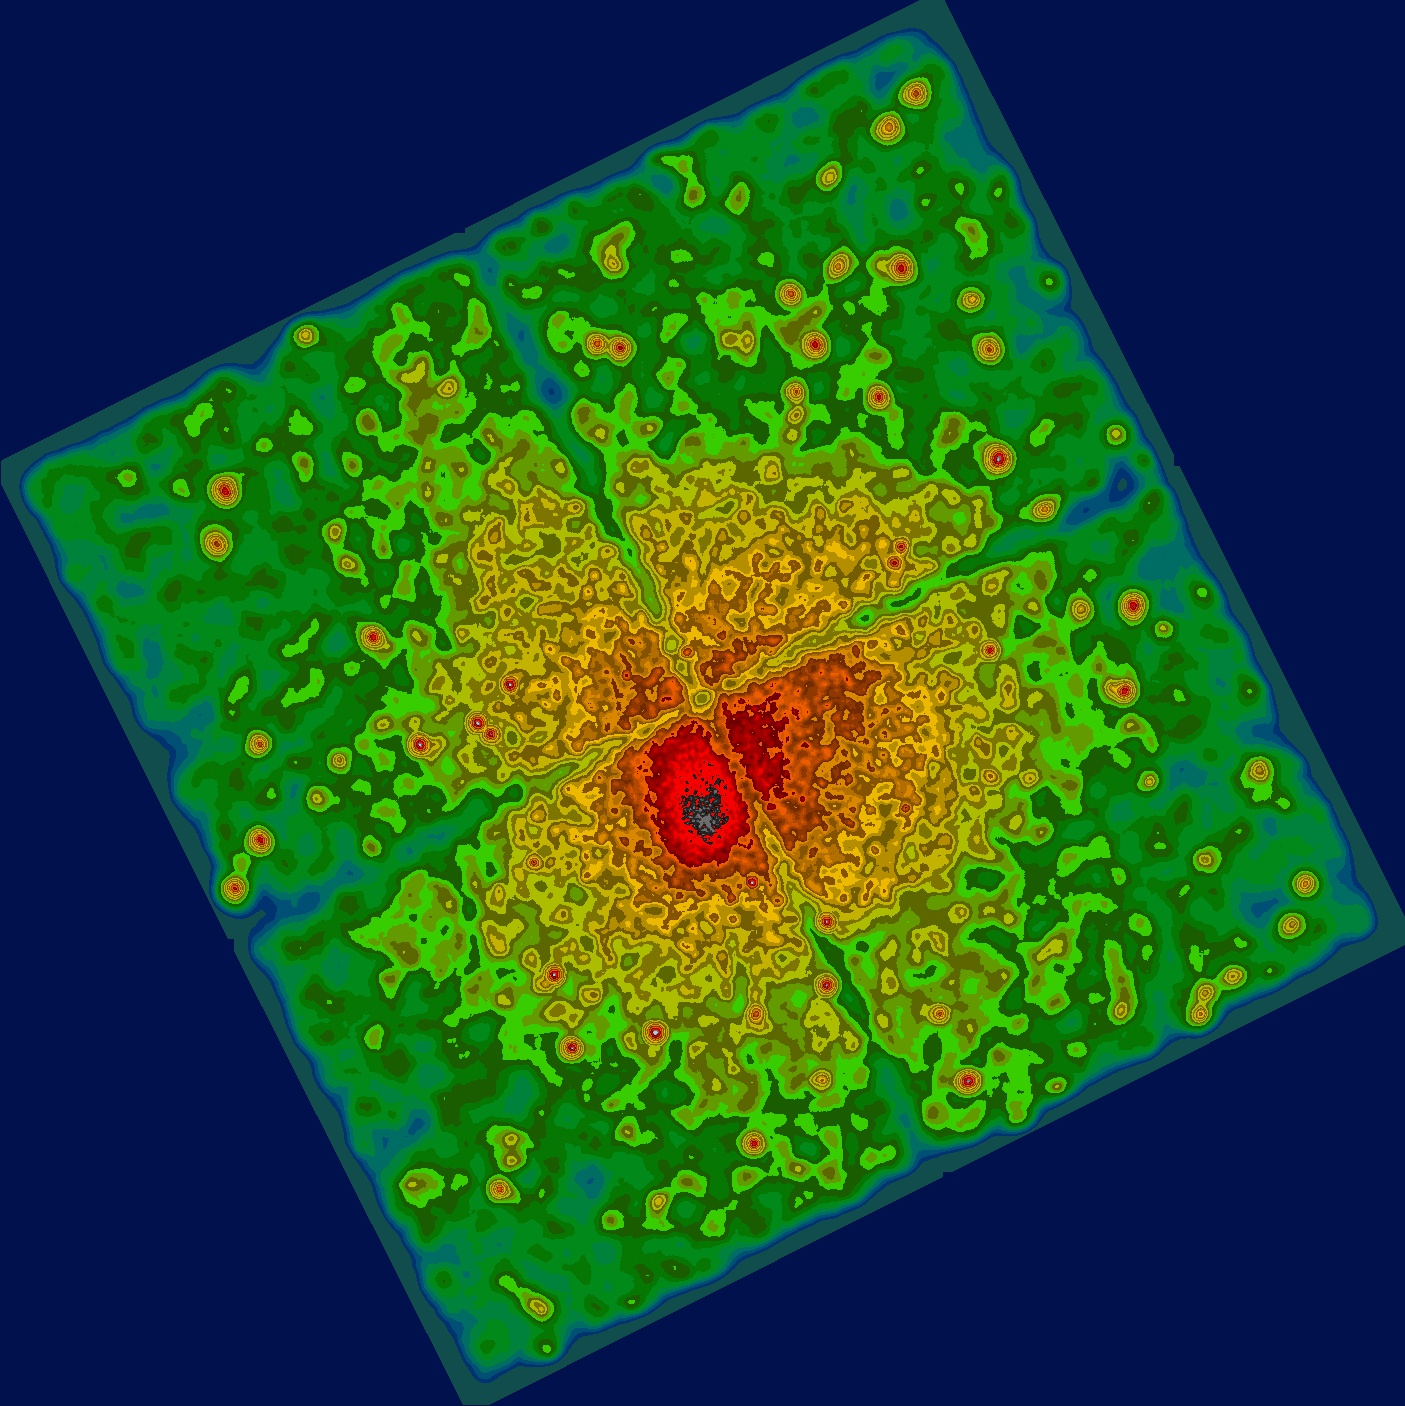

In [15]:
dmimg2jpg broad.radii outfile=broad_radii.jpg mode=h clob+ \
  scalefun=linear lutfile=")imagej_lut.16_ramps" minred=0 maxred=30
display < broad_radii.jpg


## Smooth expmap


In [16]:
dmimgcalc broad.expmap none ones.fits op="imgout=(1.0+(img1-img1))" clob+


In [17]:
punlearn dmimgadapt
pset dmimgadapt \
  infile=broad.expmap \
  outfile=broad_smooth.expmap \
  inradfile=broad.radii \
  innormfile=ones.fits \
  function=quad 
dmimgadapt mode=h clobber=yes 

# dmimgadapt (CIAO 4.9): The following error occurred 848314 times:



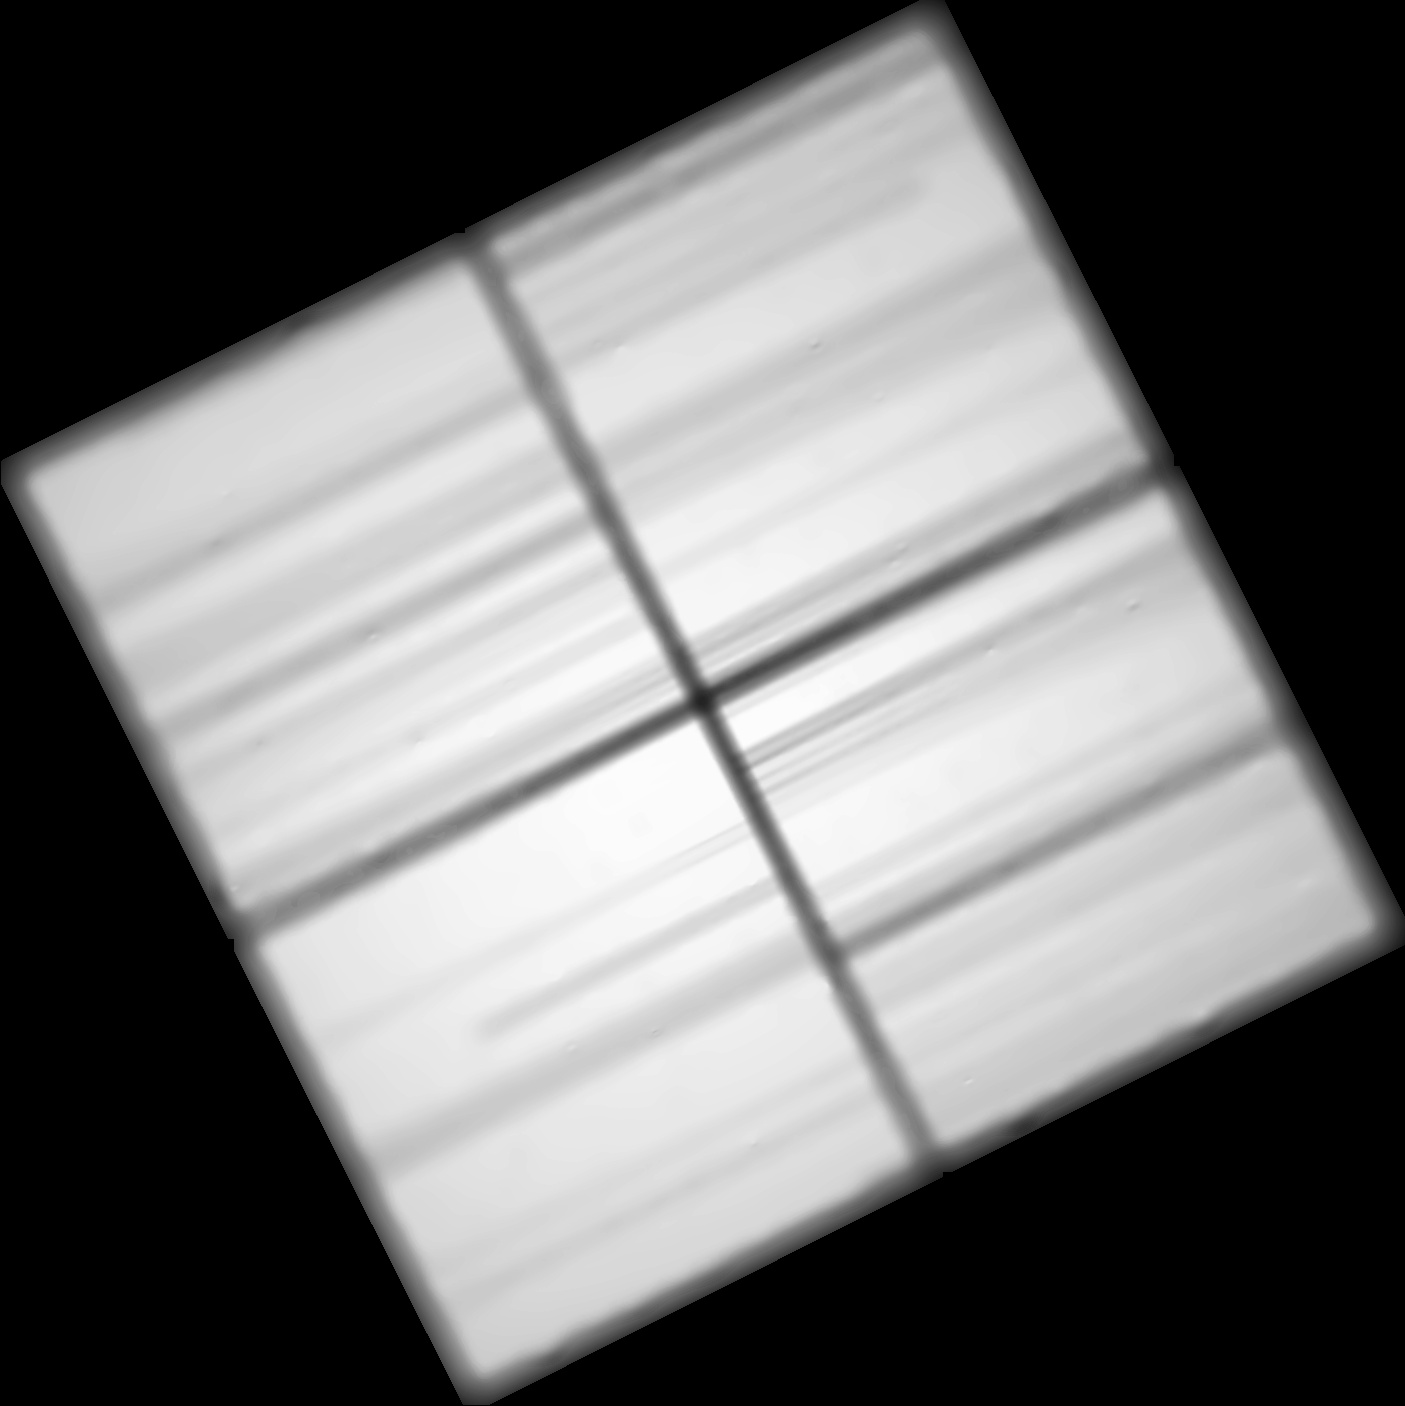

In [18]:
punlearn dmimg2jpg
dmimg2jpg broad_smooth.expmap outfile=broad_smooth_expmap.jpg scalefun=linear \
  mode=h clob+ minred=0 maxred=13085488
display < broad_smooth_expmap.jpg

## Exposure corrected


In [19]:
dmimgcalc broad_smooth.img broad_smooth.expmap broad_smooth.flux div clob+

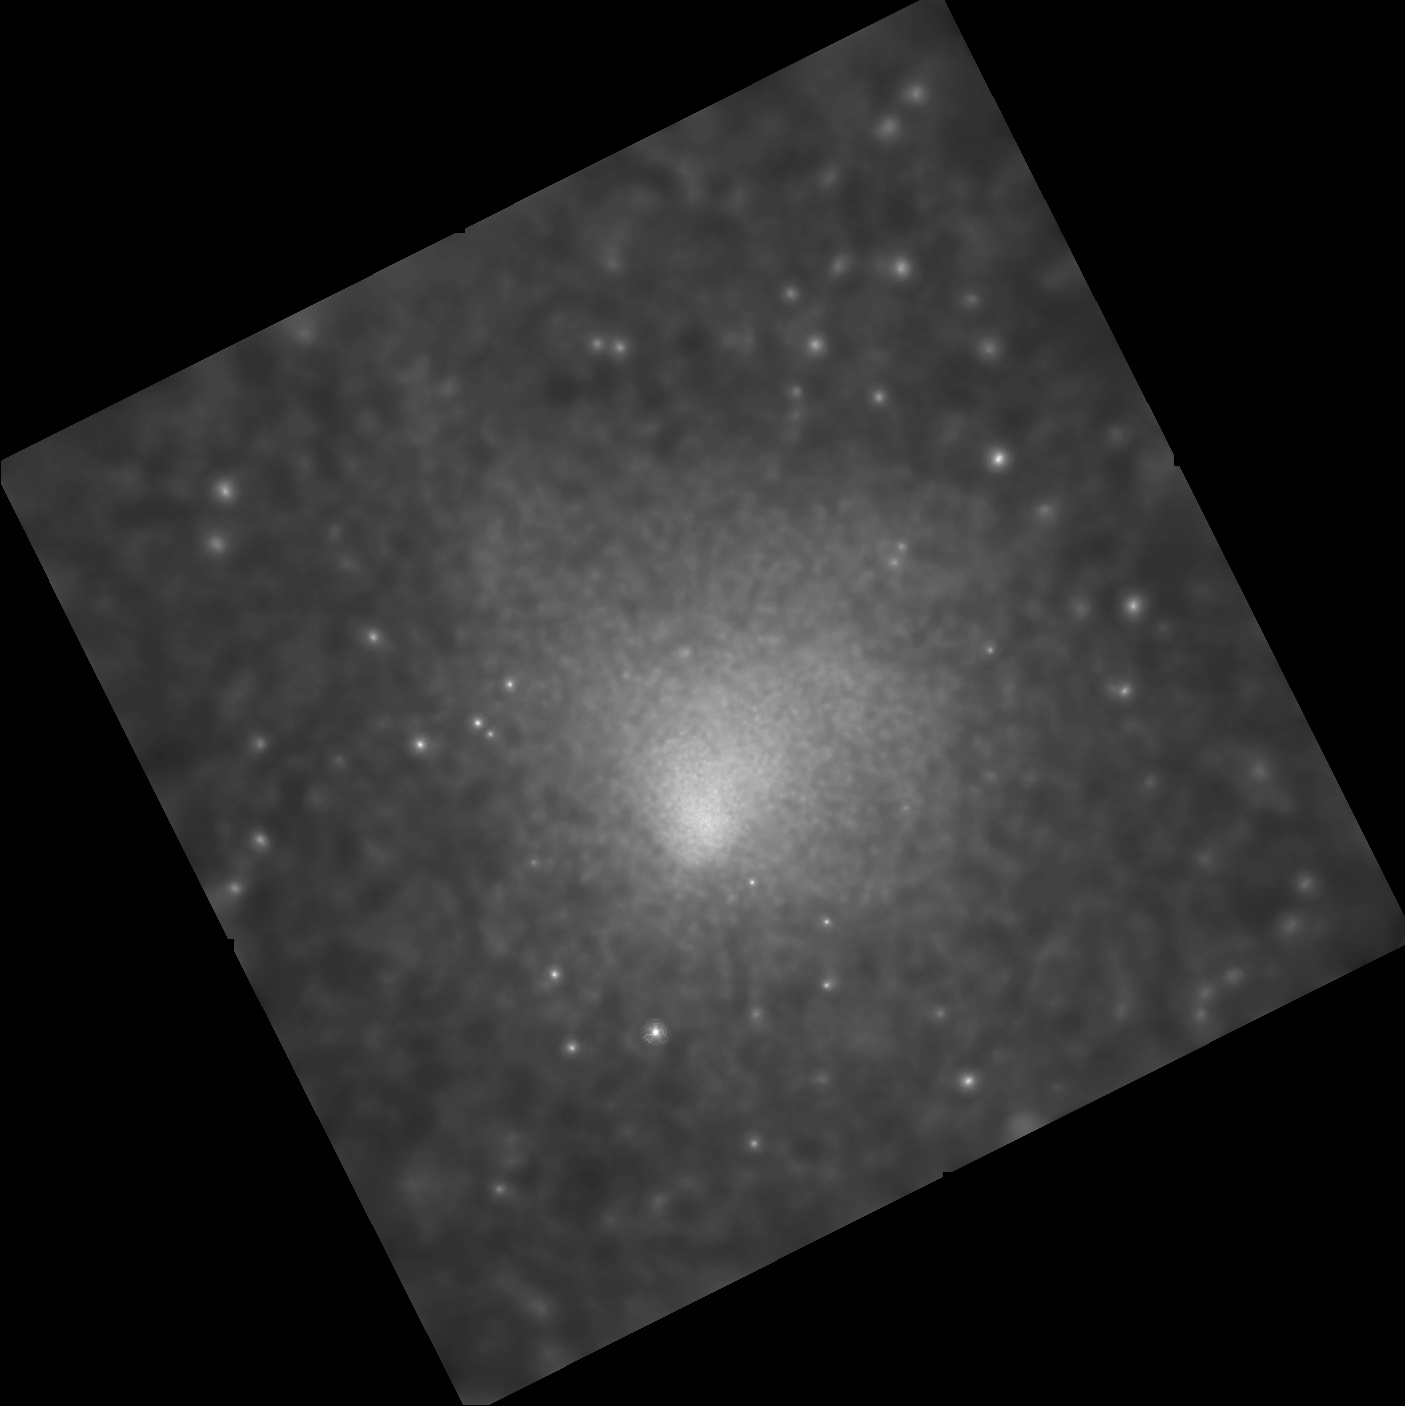

In [20]:
punlearn dmimg2jpg
dmimg2jpg broad_smooth.flux outfile=broad_smooth_flux.jpg scalefun=log \
  mode=h clob+ minred=0 maxred=1e-06
display < broad_smooth_flux.jpg

# Cleanup


In [ ]:
/bin/rm -rf 13201
/bin/rm -f acisf*.fits acisf*.lis
/bin/rm -f pcadf*.fits
